# scSVC reconstructs whole-genome profiles of Xenium datasets and defines fine-grained subtypes of T cells

## Notebook Guide

**Purpose.** Analyze reconstructed T-cell states and compare iST-SVC signals against raw Xenium measurements.

**Inputs.** Executed T-cell reconstruction outputs under `../../output/sc_SVC_case/P5CRC_Xenium/T/` plus raw Xenium data.

**Outputs.** Subtype spatial maps, marker dot plots, volcano plots, and enrichment summaries displayed inline and saved to disk.

**Reading order.**
1. Load reconstructed SVCs
2. Visualize T-cell subtypes
3. Quantify differential genes and pathways
4. Compare raw and reconstructed signals

**Reproducibility note.** `revise` imports are standard package imports from the installed `revise-svc` distribution; this notebook does not modify `sys.path` to import the repository source tree.


In [1]:
import os
os.environ.setdefault("TQDM_DISABLE", "1")
os.environ.setdefault("TQDM_MININTERVAL", "60")

try:
    from IPython import get_ipython
    _ipython = get_ipython()
    if _ipython is not None:
        _ipython.run_line_magic("matplotlib", "inline")
except Exception:
    pass

output_dir = "../../output/sc_SVC_case/P2CRC_Xenium"
select_ct = "T"


## Load Reconstructed SVCs

Load the executed reconstruction outputs that drive the downstream figures.


In [2]:
import os
import scanpy as sc

from revise.backend.runners.sc_svc_application import ScSVCAnalysis
import pandas as pd
try:
    import gseapy as gp
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError('Install pathway dependencies with pip install \"revise-svc[pathway]\"') from exc
import revise.analysis.bio as _revise_bio

_EMPTY_ENRICHMENT_COLUMNS = [
    "Gene_set",
    "Term",
    "Overlap",
    "P-value",
    "Adjusted P-value",
    "Old P-value",
    "Old Adjusted P-value",
    "Odds Ratio",
    "Combined Score",
    "Genes",
]

def _get_enrichment_human_compatible(deg_genes, geneset_file, cutoff=0.05):
    if not deg_genes:
        return pd.DataFrame(columns=_EMPTY_ENRICHMENT_COLUMNS)
    try:
        enr = gp.enrichr(
            gene_list=deg_genes,
            gene_sets=geneset_file,
            organism="human",
            cutoff=cutoff,
        )
        return enr.results
    except Exception as exc:
        print(f"Skipping enrichment analysis: {type(exc).__name__}: {exc}")
        return pd.DataFrame(columns=_EMPTY_ENRICHMENT_COLUMNS)

_revise_bio.get_enrichment = _get_enrichment_human_compatible


svc_save_dir = f"{output_dir}/{select_ct}"
sc_svc_expr = sc.read_h5ad(f"{svc_save_dir}/sc_SVC_expr.h5ad")
sc_svc_spatial = sc.read_h5ad(f"{svc_save_dir}/sc_SVC_spatial.h5ad")

sc_svc_analysis = ScSVCAnalysis(sc_svc_spatial, sc_svc_expr, 
                            "SVC_cluster")
# Legacy notebooks use these aliases in downstream result and plotting cells.
sc_SVC_adata = sc_svc_analysis.sc_SVC_adata_spatial.copy()
adata_sp = sc_svc_analysis.sc_SVC_adata_spatial.copy()
adata_sc = sc_svc_analysis.sc_SVC_adata_expr.copy()


/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/jiaoyifeng/miniconda3/envs/brainbeacon/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Conducting differential expression analysis...


In [3]:
cm_df = sc_svc_analysis.get_cm_df("Level2")
cm_df

/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/jiaoyifeng/miniconda3/envs/brainbeacon/lib/python3.9/site-packages/revise/backend/runners/sc_svc_application.py:67: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = self.sc_SVC_adata_expr.obs.groupby([self.cluster_col, sub_cell_type_col]).size()


Level2,CD4T,CD8T,NK,Tprolif
SVC_cluster,,,,
0,553,6,0,57
1,22,3,0,262
2,164,1098,99,73
3,498,85,1,7
4,712,50,0,32
5,819,7,0,31
6,197,99,53,36


/tmp/ipykernel_33723/2520313853.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', lut=10)


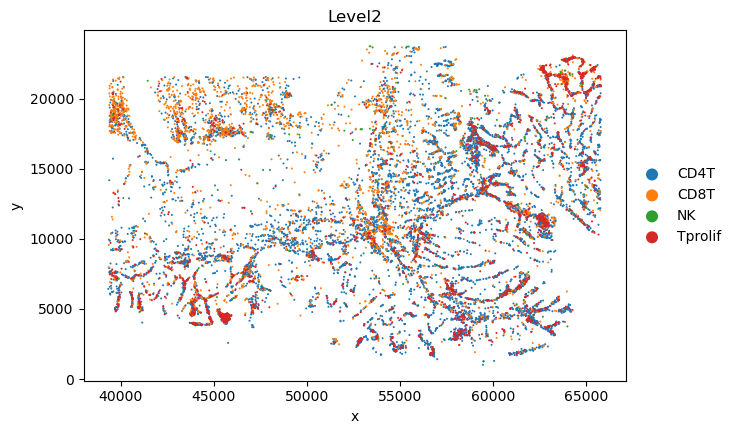

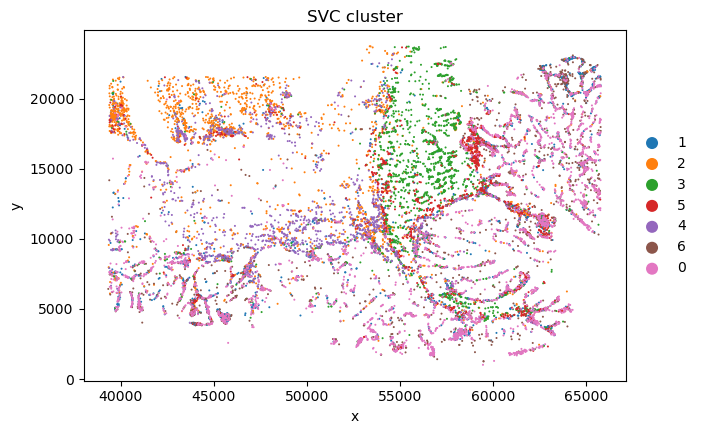

In [4]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors 

size = None
cmap = plt.cm.get_cmap('tab20', lut=10)
palette = [mcolors.to_hex(cmap(i)) for i in range(cmap.N)]

sc.pl.scatter(sc_svc_analysis.sc_SVC_adata_spatial, x="x", y="y",
              color='Level2',
              size=size)
desired_order = ['1', '2', '3', '5', '4', '6', '0']  # for better visualization
current_categories = sc_svc_analysis.sc_SVC_adata_spatial.obs['SVC_cluster'].cat.categories.astype(str).tolist()
ordered_categories = [cat for cat in desired_order if cat in current_categories]
ordered_categories += [cat for cat in current_categories if cat not in ordered_categories]
sc_svc_analysis.sc_SVC_adata_spatial.obs['SVC_cluster'] = (
    sc_svc_analysis.sc_SVC_adata_spatial.obs['SVC_cluster'].cat.reorder_categories(ordered_categories, ordered=True)
)
sc.pl.scatter(sc_svc_analysis.sc_SVC_adata_spatial, x="x", y="y",
              color='SVC_cluster',
              size=size)

## Spatial Subtype Maps

Display reconstructed spatial cell states and side-by-side annotation comparisons.


<Figure size 1000x800 with 0 Axes>

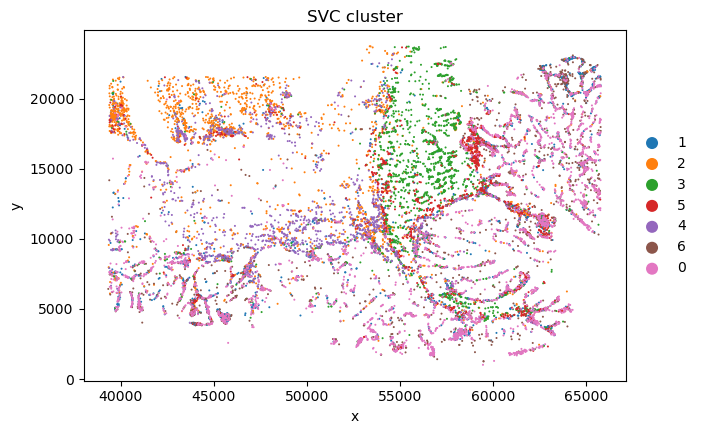

<Figure size 1000x1600 with 0 Axes>

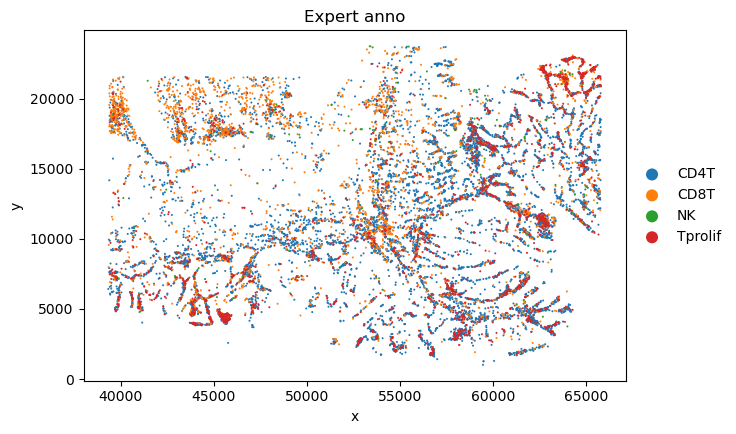

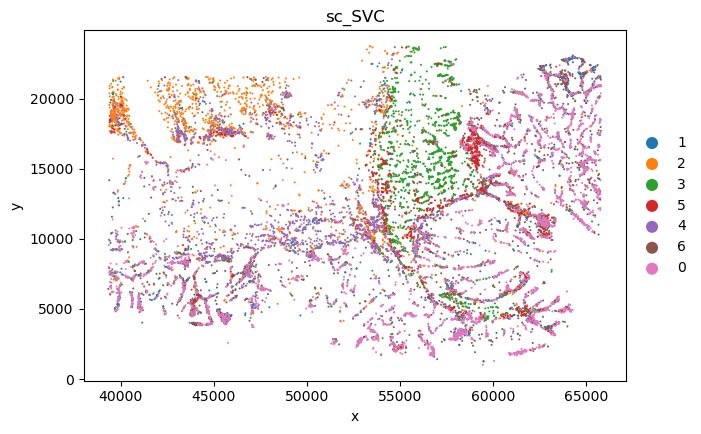

In [5]:
import matplotlib.pyplot as plt
def plot_sc_SVC(adata, color, title = None, file_name = None):

    colors = color if isinstance(color, (list, tuple)) else [color]
    titles = title if isinstance(title, (list, tuple)) else [title] * len(colors)
    plt.figure(figsize=(10, 8*len(colors)))
    for color_key, plot_title in zip(colors, titles):
        sc.pl.scatter(
            adata, x="x", y="y",
            color=color_key,
            title=plot_title, show=False,
        )
    plt.savefig(file_name, dpi = 300)
    plt.show()
    plt.close()

sc_SVC_file_name = f"{output_dir}/sc_SVC.png"
plot_sc_SVC(sc_svc_analysis.sc_SVC_adata_spatial, color='SVC_cluster',
            file_name=sc_SVC_file_name
            )

sc_SVC_file_name = f"{output_dir}/compare.png"
plot_sc_SVC(sc_svc_analysis.sc_SVC_adata_spatial, color=['Level2','SVC_cluster'],
            title=["Expert anno", "sc_SVC"],
            file_name=sc_SVC_file_name
            )

## bioinfo analysis

In [6]:
cluster_nums = ['1','3','5']
fc_threshold = 1
pathway_num = 20
gene_num = 60
geneset_file = ["MSigDB_Hallmark_2020"]
pathway_file_name = f"{output_dir}/pathway_{fc_threshold}_{pathway_num}.txt"
all_pathway = sc_svc_analysis.get_pathway_conclusion(
    cluster_nums, fc_threshold=fc_threshold, pathway_num=pathway_num, gene_num=gene_num, geneset_file=geneset_file, normalize=True)
all_pathway.to_csv(pathway_file_name)
all_pathway

/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/jiaoyifeng/miniconda3/envs/brainbeacon/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


Conducting differential expression analysis...


Cluster 1: 
Up-regulated genes: ['MKI67', 'TYMS', 'HIST1H1B', 'TUBB', 'HMGB2', 'HIST1H1C', 'ACTB', 'RRM2', 'LMNB1', 'TOP2A', 'HIST1H4C', 'PFN1', 'VIM', 'CFL1', 'HIST1H1D', 'TPX2', 'NUSAP1', 'NCAPG2', 'TACC3', 'HIST1H2BH', 'CENPM', 'MCM7', 'SMC4', 'KIF11', 'CRIP1', 'HNRNPA2B1', 'MCM4', 'KIFC1', 'LCP1', 'PHF19', 'NCAPG', 'HJURP', 'IDH2', 'PCLAF', 'H2AFZ', 'CEP55', 'ZWINT', 'TUBA1B', 'CDK1', 'CORO1A', 'ANP32E', 'NDC80', 'TMSB10', 'KIF22', 'TMPO', 'HMMR', 'EZH2', 'COTL1', 'TCF19', 'MCM2', 'CENPF', 'LMNB2', 'PLK1', 'BUB1', 'TK1', 'SMC2', 'FANCI', 'TUBB4B', 'HELLS', 'RRM1']
Enriched pathways: ['E2F Targets' 'G2-M Checkpoint' 'Mitotic Spindle' 'mTORC1 Signaling'
 'Myc Targets V1' 'PI3K/AKT/mTOR  Signaling' 'Spermatogenesis'
 'Myc Targets V2' 'Pperoxisome' 'DNA Repair' 'Apoptosis' 'Glycolysis'
 'Estrogen Response Late' 'Apical Junction'
 'Epithelial Mesenchymal Transition' 'Protein Secretion'
 'Bile Acid Metabolism' 'Oxidative Phosphorylation' 'KRAS Signaling Up'
 'Complement']



Cluster 3: 
Up-regulated genes: ['CCL5', 'IL7R', 'GZMA', 'MUC12', 'CEACAM5', 'TC2N', 'FABP1', 'PIGR', 'ERN1', 'KLRK1', 'APOBR', 'ITGA1', 'CD8A', 'SORL1', 'KLRG1', 'EPHA1', 'SYTL2', 'LY9', 'CD300A', 'OLFM4', 'MATK', 'GSAP', 'TRGC1', 'GPR15', 'PTGER2', 'ADRB2', 'ERMP1', 'PPIAL4G', 'CTSW', 'RALGPS1', 'AOAH', 'NELL2', 'MYO1D', 'LRFN1', 'KRT8', 'GZMK', 'GPR35', 'CAPRIN2', 'CEBPD', 'SNTB1', 'SMAGP', 'ARRDC5', 'VPS9D1', 'COLQ', 'PRR5L', 'PLAC8', 'ACVR1B', 'PI3', 'MYBL1', 'SPEF2', 'TRGC2', 'BMP1', 'SCART1', 'PLCB1', 'LGALS4', 'FCRL6', 'RNFT1', 'TRMT10B', 'FLT4', 'RNF157']
Enriched pathways: ['Inflammatory Response' 'TNF-alpha Signaling via NF-kB'
 'Allograft Rejection' 'KRAS Signaling Up' 'Interferon Gamma Response'
 'Complement' 'Estrogen Response Early'
 'Epithelial Mesenchymal Transition' 'p53 Pathway' 'Hypoxia'
 'Xenobiotic Metabolism' 'IL-2/STAT5 Signaling' 'Fatty Acid Metabolism'
 'Androgen Response' 'Unfolded Protein Response'
 'PI3K/AKT/mTOR  Signaling' 'Apical Junction' 'IL-6/JAK/STAT

Cluster 5: 
Up-regulated genes: ['FOXP3', 'IGHG3', 'LTB', 'MAF', 'TBC1D4', 'TIGIT', 'CCR4', 'ICOS', 'RTKN2', 'TNFRSF18', 'CTLA4', 'PIM2', 'DGKA', 'IL2RA', 'CCR8', 'SELL', 'LAYN', 'TNFRSF4', 'NABP1', 'IL1R1', 'CD27', 'ZC3H12D', 'CCR6', 'STAM', 'LINC02694', 'CD80', 'CCDC141', 'SOCS3', 'CSF1', 'SESN3', 'MAST4', 'IKZF2', 'TTN', 'ADAT2', 'PLCL1', 'F5', 'COL9A2', 'ENTPD1', 'IKZF4', 'KCNC3', 'CSF2RB', 'CD177', 'IL1R2', 'MCF2L2', 'WHRN', 'PITPNM2', 'ACAD11', 'NTNG2', 'BCL2L11', 'MAP1LC3A', 'PLA2G4C', 'SYNGAP1', 'CYSLTR1', 'SLC35D2', 'INPP5F', 'TSHZ2', 'FBLN7', 'CYP7B1', 'SOGA3', 'NINJ1']
Enriched pathways: ['IL-2/STAT5 Signaling' 'IL-6/JAK/STAT3 Signaling'
 'TNF-alpha Signaling via NF-kB' 'Allograft Rejection'
 'Inflammatory Response' 'Interferon Alpha Response'
 'Interferon Gamma Response' 'Estrogen Response Early' 'KRAS Signaling Dn'
 'Xenobiotic Metabolism' 'UV Response Up' 'p53 Pathway'
 'Protein Secretion' 'Androgen Response' 'Bile Acid Metabolism'
 'Unfolded Protein Response' 'Apical Jun

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,group
0,MSigDB_Hallmark_2020,E2F Targets,22/200,3.112157e-29,6.224314e-28,0,0,64.276168,4219.065275,TOP2A;TCF19;HELLS;RRM2;MCM7;TUBB;PLK1;HMGB2;KI...,1
1,MSigDB_Hallmark_2020,G2-M Checkpoint,19/200,5.976739e-24,5.976739e-23,0,0,50.589004,2705.204861,TOP2A;PLK1;KIF11;KIF22;HMMR;MKI67;SMC4;NDC80;L...,1
2,MSigDB_Hallmark_2020,Mitotic Spindle,12/199,6.214391e-13,4.142927e-12,0,0,26.407754,742.235837,TOP2A;TPX2;CENPF;PLK1;NUSAP1;CDK1;KIF11;KIF22;...,1
3,MSigDB_Hallmark_2020,mTORC1 Signaling,6/200,2.963485e-05,1.185394e-04,0,0,11.309278,117.916863,RRM2;PLK1;MCM4;CORO1A;BUB1;MCM2,1
4,MSigDB_Hallmark_2020,Myc Targets V1,6/200,2.963485e-05,1.185394e-04,0,0,11.309278,117.916863,RRM1;MCM7;HNRNPA2B1;MCM4;TYMS;MCM2,1
...,...,...,...,...,...,...,...,...,...,...,...
19,MSigDB_Hallmark_2020,Apical Junction,1/200,4.533326e-01,4.533326e-01,0,0,1.681373,1.330183,LAYN,5
16,MSigDB_Hallmark_2020,Apoptosis,1/161,3.847172e-01,4.533326e-01,0,0,2.095339,2.001566,BCL2L11,5
17,MSigDB_Hallmark_2020,Mitotic Spindle,1/199,4.516711e-01,4.533326e-01,0,0,1.689950,1.343174,BCL2L11,5
18,MSigDB_Hallmark_2020,Adipogenesis,1/200,4.533326e-01,4.533326e-01,0,0,1.681373,1.330183,NABP1,5


## Marker And Differential Programs

Summarize marker genes, differential genes, and pathway-level signals.


Conducting differential expression analysis...


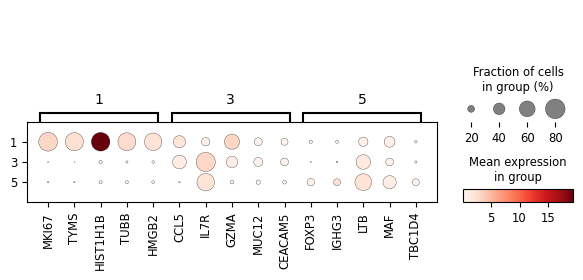

In [7]:
cluster_nums = ['1', '3', '5']

degs = sc_svc_analysis.get_svc_degs(cluster_nums, fc_threshold=1)
marker_dict = (
    degs.groupby('group')['gene']
    .apply(lambda x: x.head(5).tolist())
    .to_dict()
)
sc_svc_analysis.get_dot_plot(cluster_nums, marker_dict)

<Figure size 800x600 with 0 Axes>

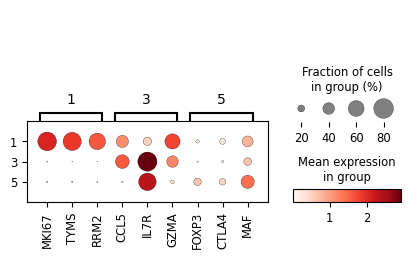

<Figure size 640x480 with 0 Axes>

In [8]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.useafm'] = False
plt.figure(figsize=(8, 6))

marker_dict = {
    '1': ['MKI67', 'TYMS', 'RRM2'],
    '3': ['CCL5', 'IL7R', 'GZMA'],
    '5': ['FOXP3', 'CTLA4', 'MAF']
    }

sc_svc_analysis.get_dot_plot(cluster_nums, marker_dict, normalize=True)
plt.savefig(f"{output_dir}/sc_SVC_dotplot.pdf", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

### sc_SVC

In [9]:
# tumor_cluster_num = '1' # Proliferation
tumor_cluster_num = '5' # Regulation

# tumor_cluster = '0' # Median
normal_cluster = '3' # normal

if tumor_cluster_num == '1':
    tumor_cluster = 'Proliferation'
elif tumor_cluster_num == '5':
    tumor_cluster = 'Regulation'

/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/jiaoyifeng/miniconda3/envs/brainbeacon/lib/python3.9/site-packages/revise/backend/runners/sc_svc_application.py:134: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  select_adata.obs['SVC_cluster'].replace(replace_cols, inplace=True)
/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/jiaoyifeng/miniconda3/envs/brainbeacon/lib/python3.9/site-packages/revise/backend/runners/sc_svc_application.py:134: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is dep

Conducting differential expression analysis...


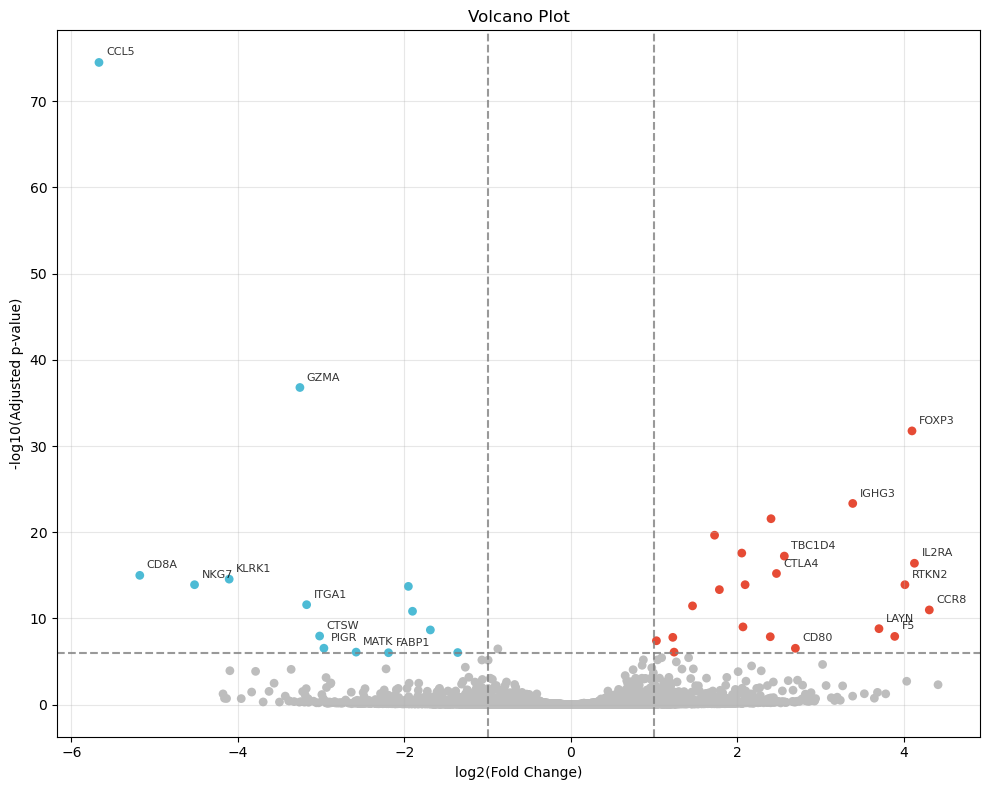

sc_SVC Regulation degs num:  89


<Figure size 640x480 with 0 Axes>

In [10]:
import pandas as pd
# for statical numbers of degs and pathways 
pvals_adj = 0.01
logfoldchanges = 1
num_df = pd.DataFrame(0, index=['sp_SC', 'raw_Xenium'], columns=['DEG', 'Pathway'])

cluster_nums = [normal_cluster, tumor_cluster_num]
replace_cols = {normal_cluster: 'Normal-infiltrated', tumor_cluster_num: 'Tumor-infiltrated'}
degs = sc_svc_analysis.get_volcano_plot(cluster_nums, target_group="Tumor-infiltrated", replace_cols=replace_cols, fc_threshold=None, log_fold_changes=10, logfc_threshold=1, padj_threshold=1e-6, top_k=10)

deg_num = ((degs['pvals_adj'] < pvals_adj) & (degs['logfoldchanges'].abs() > logfoldchanges)).sum()
print( f"sc_SVC {tumor_cluster} degs num: ", deg_num )
num_df.loc['sp_SC', 'DEG'] = deg_num

plt.savefig(f"{output_dir}/sc_SVC/{tumor_cluster}_volcano.pdf", dpi=300, bbox_inches='tight')
plt.show()


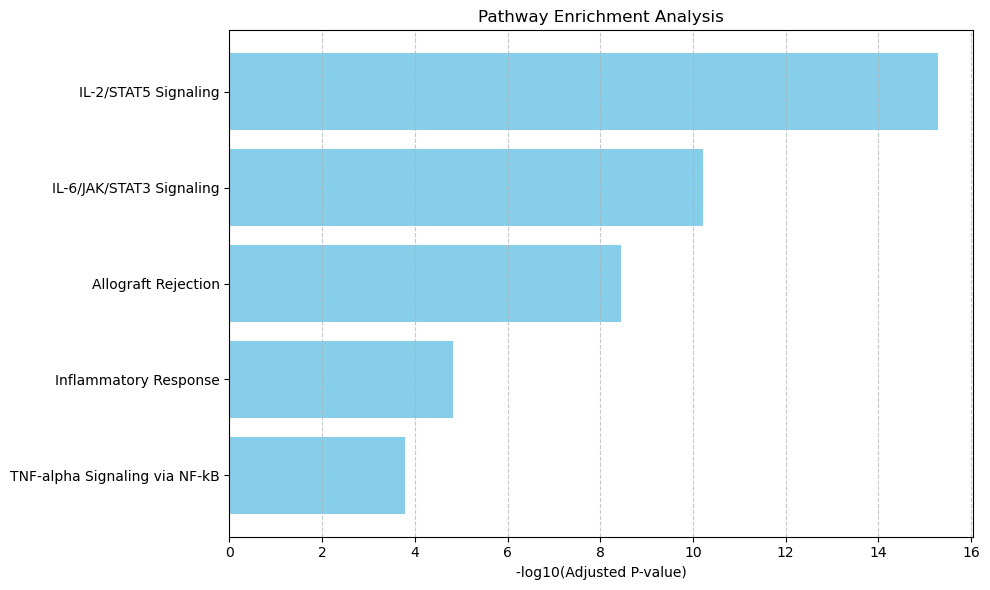

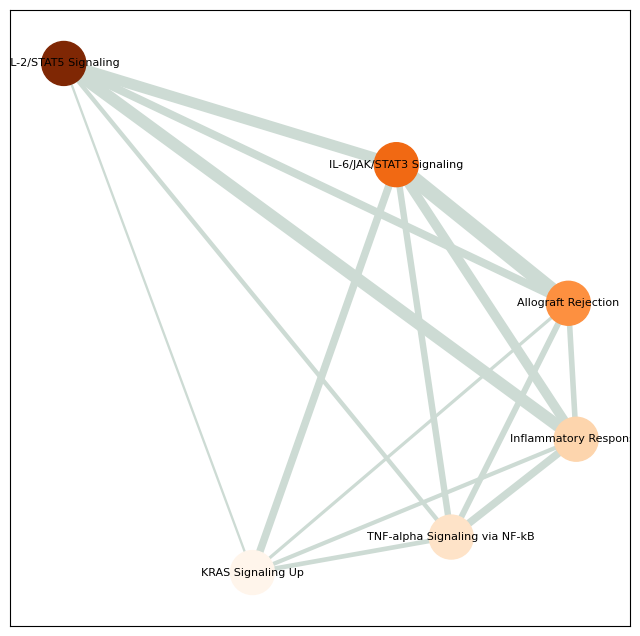

In [11]:
# for enrichment analysis
from revise.analysis.bio import get_enrichment, pathway_barplot, pathway_network_plot

degs = degs[degs['logfoldchanges'] > 0]
degs.reset_index(drop = True, inplace = True)
deg_genes = degs["gene"][:60].tolist()
pathway = get_enrichment(deg_genes, geneset_file)
pathway.to_csv(f"{output_dir}/sc_SVC/{tumor_cluster}_pathway.csv", index=False)

pathway_barplot(pathway)
pathway_network_plot(pathway, 
                     top_term = 6, 
                     save_file_name = f'{output_dir}/sc_SVC/{tumor_cluster}_network.pdf')

### raw

/tmp/ipykernel_33723/3530571688.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  raw_select_adata.obs['SVC_cluster'].replace({normal_cluster: 'Normal-infiltrated', tumor_cluster_num: 'Tumor-infiltrated'}, inplace=True)
/tmp/ipykernel_33723/3530571688.py:5: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  raw_select_

Conducting differential expression analysis...


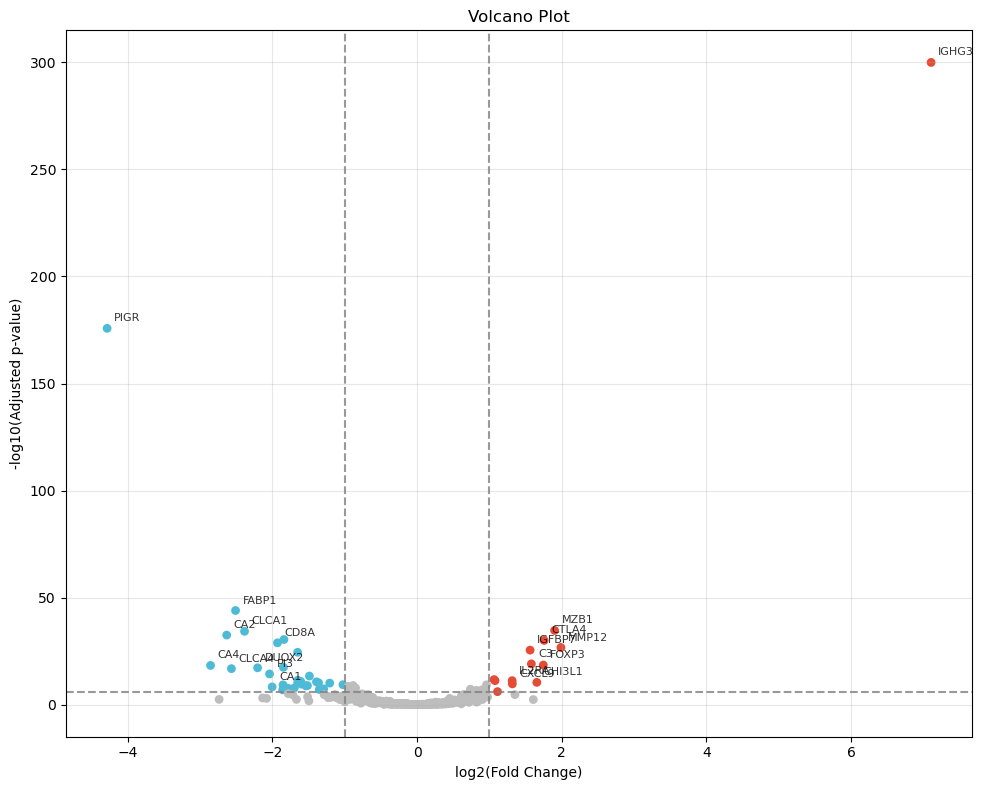

In [12]:
from revise.analysis.bio import get_degs
os.makedirs(f"{output_dir}/raw_Xenium", exist_ok=True)
sc_SVC_adata = sc_svc_analysis.sc_SVC_adata_spatial.copy()
raw_select_adata = sc_SVC_adata[sc_SVC_adata.obs['SVC_cluster'].isin([normal_cluster, tumor_cluster_num])]
raw_select_adata.obs['SVC_cluster'].replace({normal_cluster: 'Normal-infiltrated', tumor_cluster_num: 'Tumor-infiltrated'}, inplace=True)
raw_deg_df = get_degs(raw_select_adata, groupby='SVC_cluster', method='t-test', fc_threshold=None)
raw_deg_df = raw_deg_df[raw_deg_df['group'] == "Tumor-infiltrated"]
raw_deg_df.reset_index(drop = True, inplace = True)
raw_deg_df.to_csv(f"{output_dir}/raw_Xenium/{tumor_cluster}_degs.csv", index=False)

from revise.analysis.bio import plot_volcano
plot_volcano(raw_deg_df, logfc_threshold=1, padj_threshold=1e-6, 
                 top_k=10, save_file_name = f"{output_dir}/raw_Xenium/{tumor_cluster}_volcano.pdf")


Raw Xenium Regulation pathway num:  8


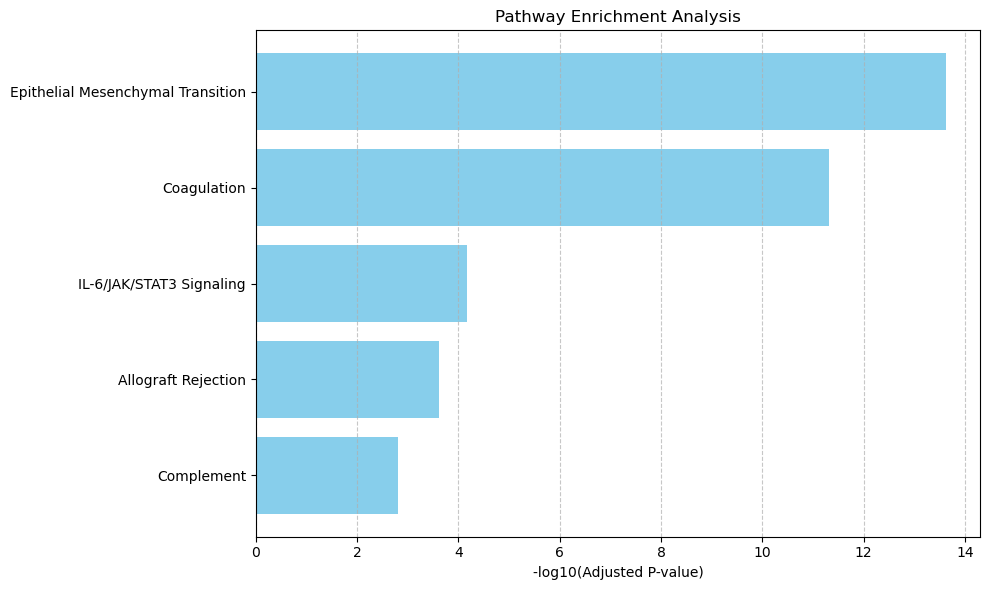

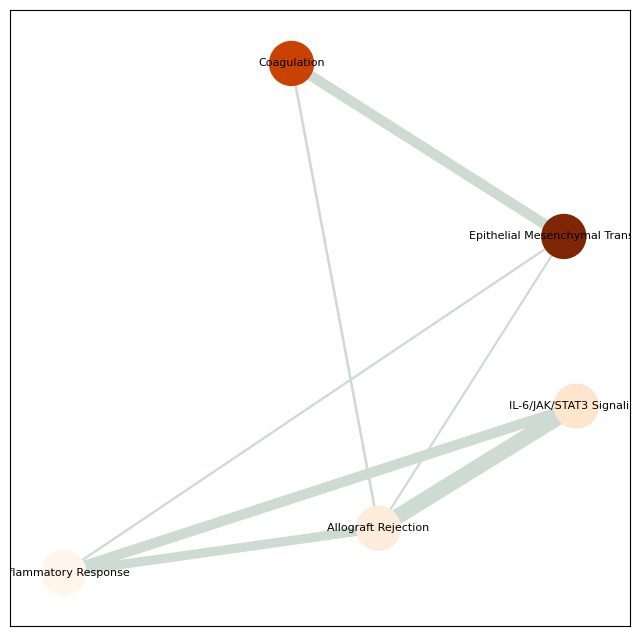

In [13]:
# for enrichment analysis
from revise.analysis.bio import get_enrichment
raw_deg_df = raw_deg_df[raw_deg_df['logfoldchanges'] > 0] # postive for up-regulated pathway
raw_deg_df.reset_index(drop = True, inplace = True)
deg_genes = raw_deg_df["gene"][:60].tolist()
pathway = get_enrichment(deg_genes, geneset_file)
pathway.to_csv(f"{output_dir}/raw_Xenium/{tumor_cluster}_pathway.csv", index=False)

raw_pathway_num = (pathway['Adjusted P-value'] < pvals_adj).sum()
print( f"Raw Xenium {tumor_cluster} pathway num: ", raw_pathway_num )
num_df.loc['raw_Xenium', 'Pathway'] = raw_pathway_num
num_df.to_csv(f"{output_dir}/sc_SVC/{tumor_cluster}_num.csv", index=False)

pathway_barplot(pathway)
pathway_network_plot(pathway, 
                     top_term = 6, 
                     save_file_name = f'{output_dir}/raw_Xenium/{tumor_cluster}_network.pdf')

Raw Xenium Regulation pathway num:  8


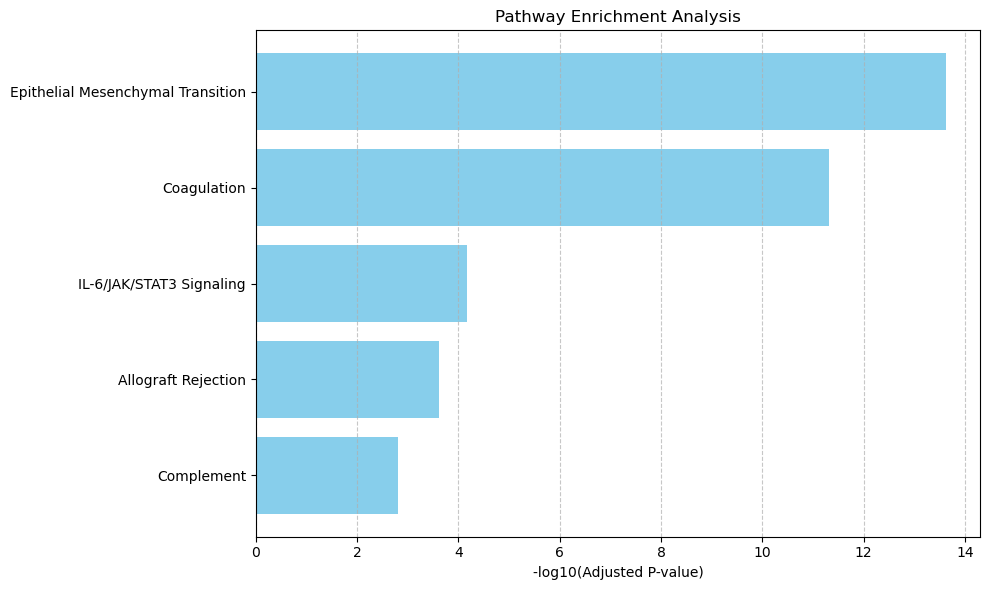

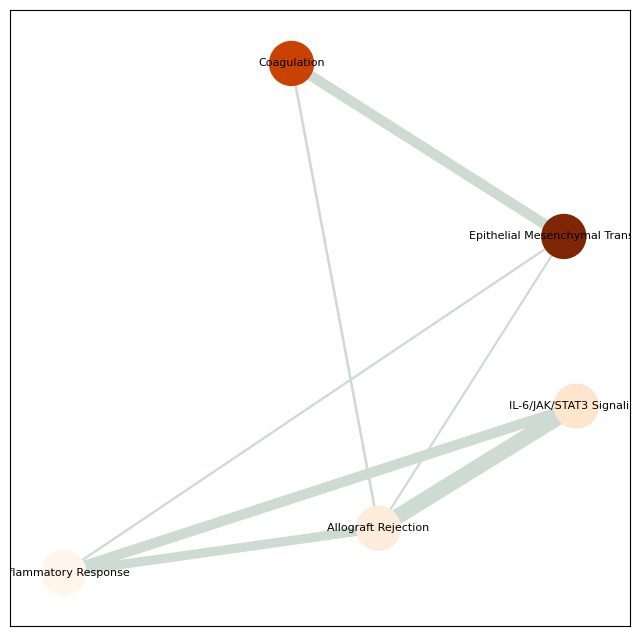

In [14]:
# for enrichment analysis
from revise.analysis.bio import get_enrichment
raw_deg_df = raw_deg_df[raw_deg_df['logfoldchanges'] > 0] # postive for up-regulated pathway
raw_deg_df.reset_index(drop = True, inplace = True)
deg_genes = raw_deg_df["gene"][:60].tolist()
pathway = get_enrichment(deg_genes, geneset_file)
pathway.to_csv(f"{output_dir}/raw_Xenium/{tumor_cluster}_pathway.csv", index=False)
raw_pathway_num = (pathway['Adjusted P-value'] < pvals_adj).sum()
print( f"Raw Xenium {tumor_cluster} pathway num: ", raw_pathway_num )
num_df.loc['raw_Xenium', 'Pathway'] = raw_pathway_num
num_df.to_csv(f"{output_dir}/sc_SVC/{tumor_cluster}_num.csv", index=False)

pathway_barplot(pathway)
pathway_network_plot(pathway, 
                     top_term = 6, 
                     save_file_name = f'{output_dir}/raw_Xenium/{tumor_cluster}_network.pdf')